<a href="https://colab.research.google.com/github/elenafoppoli05-gif/brayton-cycle-analysis/blob/main/BraytonCycle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
gamma = 1.4
cp=1005 #J/KgK (air)

T1=300 #inlet temperature
T3=1400 #maximum temperature

rp = np.linspace(2, 20, 100)  # pressure ratio

eta = []

for r in rp:

    # 1 → 2 (isentropic compression)
    T2 = T1 * r**((gamma - 1)/gamma)

    # 3 → 4 (isentropic expansion)
    T4 = T3 * r**(-(gamma - 1)/gamma)

    # compressor and turbine work
    Wc = cp * (T2 - T1)
    Wt = cp * (T3 - T4)
    Wnet = Wt - Wc

    # heat input
    Qin = cp * (T3 - T2)

    # thermal efficiency
    eta.append(Wnet / Qin)

eta = np.array(eta)

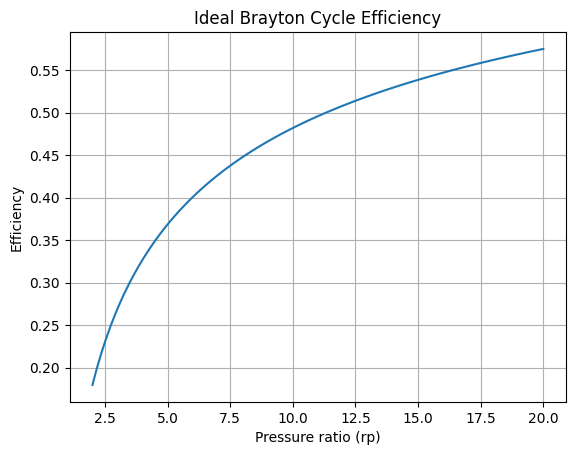

In [ ]:
plt.plot(rp, eta)
plt.xlabel("Pressure ratio (rp)")
plt.ylabel("Efficiency")
plt.title("Ideal Brayton Cycle Efficiency")
plt.grid()
plt.show()

In [ ]:
gamma = 1.4
cp = 1005
R = 287

T1 = 300
T3 = 1400
r = 10  # one pression chosen

# states
T2 = T1 * r**((gamma - 1)/gamma)
T4 = T3 * r**(-(gamma - 1)/gamma)

# entropy (relative)
s1 = 0
s2 = cp * np.log(T2/T1)
s3 = s2
s4 = s3 + cp * np.log(T4/T3)

T = [T1, T2, T3, T4, T1]
s = [s1, s2, s3, s4, s1]


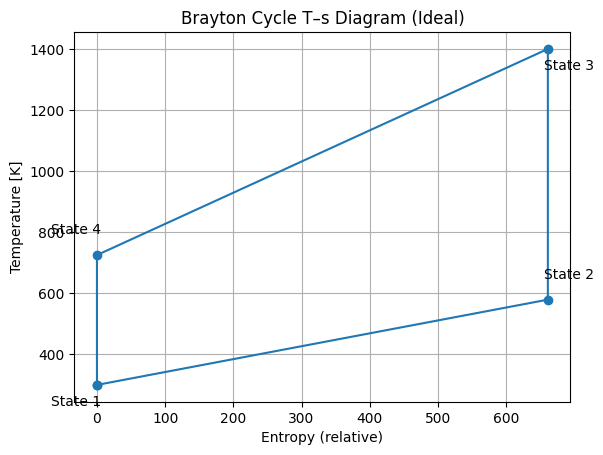

In [ ]:
plt.plot(s, T, marker='o')
plt.xlabel("Entropy (relative)")
plt.ylabel("Temperature [K]")
plt.title("Brayton Cycle T–s Diagram (Ideal)")
plt.grid()

# Add labels to the points
plt.annotate('State 1', (s[0], T[0]), textcoords="offset points", xytext=(-15,-15), ha='center')
plt.annotate('State 2', (s[1], T[1]), textcoords="offset points", xytext=(15,15), ha='center')
plt.annotate('State 3', (s[2], T[2]), textcoords="offset points", xytext=(15,-15), ha='center')
plt.annotate('State 4', (s[3], T[3]), textcoords="offset points", xytext=(-15,15), ha='center')

plt.show()

In [ ]:
eta_c = 0.85  # compressor efficiency
eta_t = 0.88  # turbine efficiency

In [ ]:
eta_real = []

for r in rp:

    # IDEAL temperatures
    T2s = T1 * r**((gamma - 1)/gamma)
    T4s = T3 * r**(-(gamma - 1)/gamma)

    # REAL compressor exit temperature
    T2 = T1 + (T2s - T1) / eta_c

    # REAL turbine exit temperature
    T4 = T3 - eta_t * (T3 - T4s)

    # work
    Wc = cp * (T2 - T1)
    Wt = cp * (T3 - T4)
    Wnet = Wt - Wc

    # heat input
    Qin = cp * (T3 - T2)

    eta_real.append(Wnet / Qin)

eta_real = np.array(eta_real)

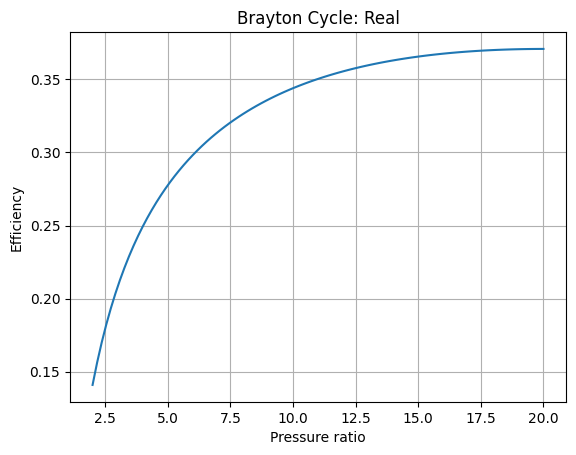

In [ ]:
plt.plot(rp, eta_real, label="Real cycle")

plt.xlabel("Pressure ratio")
plt.ylabel("Efficiency")
plt.title("Brayton Cycle: Real")
plt.grid()
plt.show()

In [ ]:
eta = []
Wnet_list = []

for r in rp:

    # ideal states
    T2 = T1 * r**((gamma - 1)/gamma)
    T4 = T3 * r**(-(gamma - 1)/gamma)

    # work
    Wc = cp * (T2 - T1)
    Wt = cp * (T3 - T4)
    Wnet = Wt - Wc

    Qin = cp * (T3 - T2)

    eta.append(Wnet / Qin)
    Wnet_list.append(Wnet)

eta = np.array(eta)
Wnet_list = np.array(Wnet_list)

In [ ]:
i_eta = np.argmax(eta)
rp_eta_opt = rp[i_eta]

print("Max efficiency at rp =", rp_eta_opt)
print("Max efficiency =", eta[i_eta])

Max efficiency at rp = 20.0
Max efficiency = 0.5751093795080316


In [ ]:
i_w = np.argmax(Wnet_list)
rp_w_opt = rp[i_w]

print("Max work at rp =", rp_w_opt)
print("Max work =", Wnet_list[i_w])

Max work at rp = 14.727272727272728
Max work = 405869.15561899764


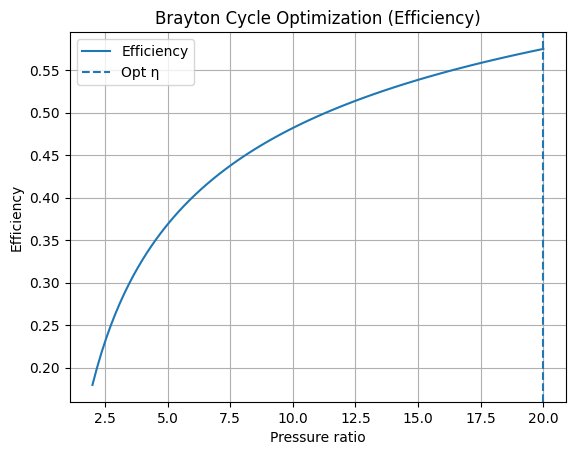

In [ ]:
plt.plot(rp, eta, label="Efficiency")
plt.axvline(rp_eta_opt, linestyle="--", label="Opt η")

plt.xlabel("Pressure ratio")
plt.ylabel("Efficiency")
plt.title("Brayton Cycle Optimization (Efficiency)")
plt.grid()
plt.legend()
plt.show()

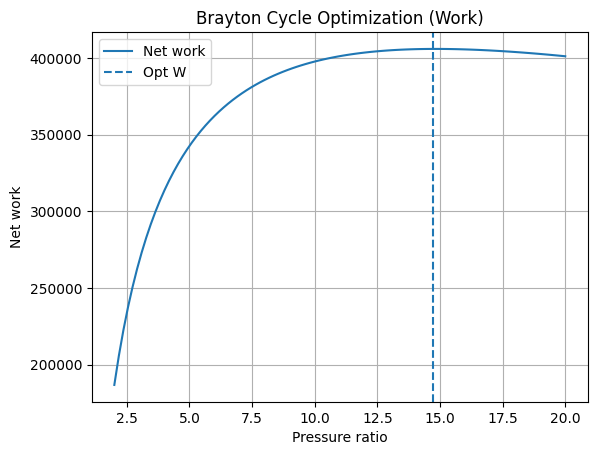

In [ ]:
plt.plot(rp, Wnet_list, label="Net work")
plt.axvline(rp_w_opt, linestyle="--", label="Opt W")

plt.xlabel("Pressure ratio")
plt.ylabel("Net work")
plt.title("Brayton Cycle Optimization (Work)")
plt.grid()
plt.legend()
plt.show()